# Fichier

In [64]:
# === Data manipulation ===
import numpy as np
import pandas as pd

# === Visualisation ===
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# === Machine Learning classique ===
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# === Computer Vision ===
import cv2

# === Deep Learning (PyTorch) ===
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

# === Deep Learning (TensorFlow / Keras) ===
import tensorflow as tf
keras = tf.keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50

# === NLP / Transformers ===
from transformers import pipeline, AutoTokenizer, AutoModel

import os
import random


exploration visuelle

Classes détectées : ['avec_labels', "Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt", 'sans_label']
Image non lisible : data/mri_dataset_brain_cancer_oc\avec_labels\normal


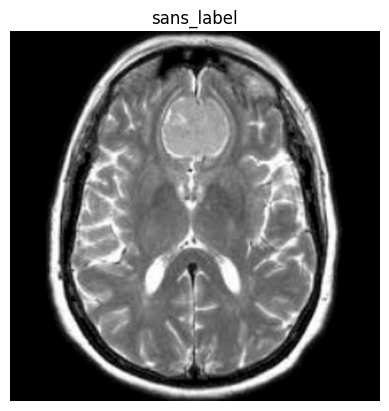

In [48]:
dataset_path = "data/mri_dataset_brain_cancer_oc"


classes = os.listdir(dataset_path)
print("Classes détectées :", classes)

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    
    # Ignore si ce n'est pas un dossier
    if not os.path.isdir(class_path):
        continue
    
    images = os.listdir(class_path)
    
    if len(images) == 0:
        continue
    
    img_path = os.path.join(class_path, random.choice(images))
    
    img = cv2.imread(img_path)
    
    if img is None:
        print(f"Image non lisible : {img_path}")
        continue
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    plt.show()

verification des dimensions

In [36]:
sizes = []
dataset_path = r"data/mri_dataset_brain_cancer_oc"

valid_extensions = (".jpg", ".jpeg", ".png")

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    for img_name in images[:50]:  # échantillon
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            print("Image corrompue ou non lisible :", img_path)
            continue
        
        sizes.append(img.shape)

print("Tailles uniques :", set(sizes))

Tailles uniques : {(512, 512, 3)}


In [37]:
print(os.listdir(r"data\mri_dataset_brain_cancer_oc"))

['avec_labels', "Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt", 'sans_label']


Explorer les données labelisées

In [38]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"

for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    if os.path.isdir(class_path):
        print(cls, ":", len(os.listdir(class_path)), "images")

cancer : 50 images
normal : 50 images


tailles des images sur **données labelisées**

In [ ]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"
valid_extensions = (".jpg", ".jpeg", ".png")

sizes = []

for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    for img_name in images[:50]:  # on échantillonne
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        sizes.append(img.shape)

print("Tailles uniques trouvées :", set(sizes))

Tailles uniques trouvées : {(512, 512, 3)}


Affichage de quelques images labelisées par classe 

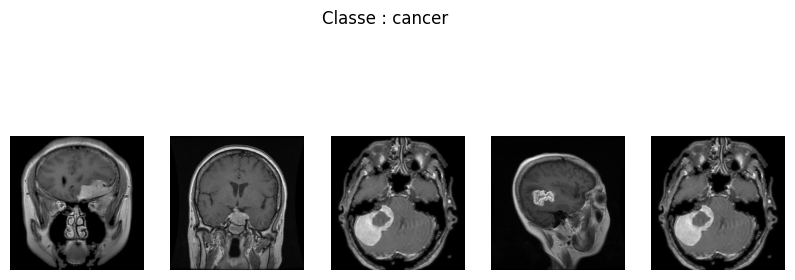

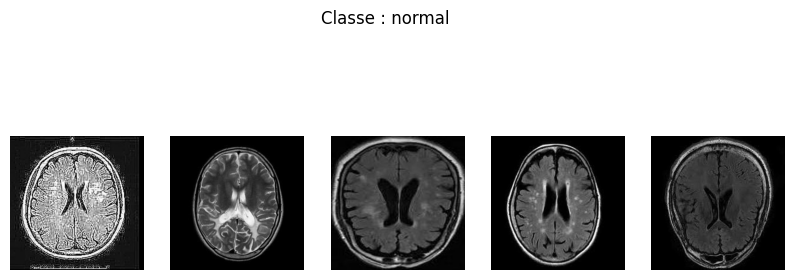

In [40]:
for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    plt.figure(figsize=(10, 4))
    
    for i in range(5):  # 5 images par classe
        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(f"Classe : {cls}")
    plt.show()

taille standard : 224x224 (ResNet)

In [41]:
img = cv2.imread(img_path)
img_resized = cv2.resize(img, (224, 224))

print("Nouvelle taille :", img_resized.shape)

Nouvelle taille : (224, 224, 3)


definition de X et y

In [51]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"
img_size = 224

X = []
y = []

classes = sorted(os.listdir(base_path)) 
print("Classes :", classes)

for label, cls in enumerate(classes):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        img = cv2.resize(img, (img_size, img_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        X.append(img)
        y.append(label)

Classes : ['cancer', 'normal']


In [52]:

X = np.array(X, dtype="float32") / 255.0   # normalisation [0, 1]
y = np.array(y)

print(f"Dataset : {X.shape}, Labels : {y.shape}")

Dataset : (100, 224, 224, 3), Labels : (100,)


In [43]:
# SPLIT TRAIN_TEST 

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

num_classes = len(classes)
print("Nombre de classes :", num_classes)

Train : (80, 224, 224, 3)
Test : (20, 224, 224, 3)
Nombre de classes : 2


# CNN 

In [ ]:
model = keras.Sequential([
    # Bloc 1
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    layers.MaxPooling2D(2, 2),

    # Bloc 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    # Bloc 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    # Classifieur
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy", # y=[0,1], pas d'encodage
    metrics=["accuracy"]
)

model.summary()


c:\Users\chris\traitement_images_semi_supervisées\venv312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

entraînement

In [57]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.4861 - loss: 1.3904 - val_accuracy: 0.7500 - val_loss: 0.6170
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 957ms/step - accuracy: 0.4167 - loss: 0.8735 - val_accuracy: 0.2500 - val_loss: 0.7174
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 630ms/step - accuracy: 0.5417 - loss: 0.6649 - val_accuracy: 0.2500 - val_loss: 0.7794
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 930ms/step - accuracy: 0.5417 - loss: 0.6438 - val_accuracy: 0.2500 - val_loss: 0.7726
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 652ms/step - accuracy: 0.5139 - loss: 0.5731 - val_accuracy: 0.6250 - val_loss: 0.6705
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 915ms/step - accuracy: 0.7778 - loss: 0.5403 - val_accuracy: 0.2500 - val_loss: 0.8089
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 816ms/step - accuracy: 0.6944 - loss: 0.4564 - val_accuracy: 0.7500 - val_loss: 0.5993
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 835ms/step - accuracy: 0.8889 - loss: 0.3911 - val_accuracy: 0.7500 - val_loss: 0.

Accuracy

In [58]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n Baseline accuracy : {accuracy * 100:.2f}%")
print(f"   Loss              : {loss:.4f}")


 Baseline accuracy : 85.00%
   Loss              : 0.4366


data augmentation car seulement 100 echantillons avac label

In [65]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

tranfer learning avec ResNet50

In [66]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # on gèle les couches

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")  # binaire
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

2 classes =>obtenir un neurone final

In [67]:
y = np.array(y).astype("float32")

In [68]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=8),
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5250 - loss: 0.7301 - val_accuracy: 0.8000 - val_loss: 0.6190
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 842ms/step - accuracy: 0.6375 - loss: 0.6457 - val_accuracy: 0.7000 - val_loss: 0.5783
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 895ms/step - accuracy: 0.6125 - loss: 0.6360 - val_accuracy: 0.7500 - val_loss: 0.5268
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 825ms/step - accuracy: 0.6125 - loss: 0.6170 - val_accuracy: 0.7500 - val_loss: 0.5343
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 927ms/step - accuracy: 0.7000 - loss: 0.5442 - val_accuracy: 0.7500 - val_loss: 0.4808
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7250 - loss: 0.5476 - val_accuracy: 0.7000 - val_loss: 0.5359
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7375 - loss: 0.5576 - val_accuracy: 0.7500 - val_loss: 0.4710
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7500 - loss: 0.5477 - val_accuracy: 0.7500 - v

prediction sans label

In [70]:
unlabeled_path = "data/mri_dataset_brain_cancer_oc/sans_label"

X_unlabeled = []

for img_name in os.listdir(unlabeled_path):
    img_path = os.path.join(unlabeled_path, img_name)
    img = cv2.imread(img_path)
    
    if img is None:
        continue
    
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    X_unlabeled.append(img)

X_unlabeled = np.array(X_unlabeled, dtype="float32") / 255.0

print("Unlabeled shape:", X_unlabeled.shape)

Unlabeled shape: (1406, 224, 224, 3)


# modele semi-supervise

In [75]:
pseudo_probs = model.predict(X_unlabeled)

44/44 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step


In [76]:
pseudo_labels = (pseudo_probs > 0.9).astype(int)

In [79]:
mask = (pseudo_probs > 0.9) | (pseudo_probs < 0.1)

X_pseudo = X_unlabeled[mask.flatten()]
y_pseudo = (pseudo_probs[mask] > 0.5).astype(int)

y_pseudo = y_pseudo.flatten() # pour avoir 1 seule dimension et non pas 2

In [80]:
print("y_train shape:", y_train.shape)
print("y_pseudo shape:", y_pseudo.shape)

y_train shape: (80,)
y_pseudo shape: (144,)


In [81]:
X_combined = np.concatenate([X_train, X_pseudo])
y_combined = np.concatenate([y_train, y_pseudo])

print(X_combined.shape)
print(y_combined.shape)

(224, 224, 224, 3)
(224,)


retrainement à nouveau

In [ ]:
history_ssl = model.fit(
    X_combined, y_combined,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=8
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 756ms/step - accuracy: 0.9152 - loss: 0.1919 - val_accuracy: 0.8000 - val_loss: 0.4933
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 21s 737ms/step - accuracy: 0.9152 - loss: 0.1796 - val_accuracy: 0.7500 - val_loss: 0.4808
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 23s 791ms/step - accuracy: 0.9464 - loss: 0.1680 - val_accuracy: 0.8000 - val_loss: 0.5190
Epoch 4/10
22/28 ━━━━━━━━━━━━━━━━━━━━ 3s 666ms/step - accuracy: 0.9619 - loss: 0.1327

In [ ]:
print("Nombre pseudo-labels retenus :", len(X_pseudo))